# IMPORTS

In [11]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import pandas as pd
import numpy as np
import csv
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import defaultdict

# MATHS GPT

In [3]:
df = pd.read_csv("/kaggle/input/final-maths-dataset/dataset.csv")

lines = []
for i in range(df.shape[0]):
    lines.append(f"{df['input'][i]}{df['output'][i]}\n")

text = "".join(lines)

## Vocabulary

In [4]:
single_digits = [str(i) for i in range(10)]
two_digits = [str(i) for i in range(10, 100)]
three_digits = [str(i) for i in range(100, 1000)] 
symbols = ["+", "-", "*", "/", "=","(", ")", "\n"]

vocab = three_digits + two_digits + single_digits + symbols
vocab_size = len(vocab)

stoi = {tok: i for i, tok in enumerate(vocab)}
itos = {i: tok for tok, i in stoi.items()}

In [5]:
print(vocab_size)

1008


In [6]:
print(stoi)

{'100': 0, '101': 1, '102': 2, '103': 3, '104': 4, '105': 5, '106': 6, '107': 7, '108': 8, '109': 9, '110': 10, '111': 11, '112': 12, '113': 13, '114': 14, '115': 15, '116': 16, '117': 17, '118': 18, '119': 19, '120': 20, '121': 21, '122': 22, '123': 23, '124': 24, '125': 25, '126': 26, '127': 27, '128': 28, '129': 29, '130': 30, '131': 31, '132': 32, '133': 33, '134': 34, '135': 35, '136': 36, '137': 37, '138': 38, '139': 39, '140': 40, '141': 41, '142': 42, '143': 43, '144': 44, '145': 45, '146': 46, '147': 47, '148': 48, '149': 49, '150': 50, '151': 51, '152': 52, '153': 53, '154': 54, '155': 55, '156': 56, '157': 57, '158': 58, '159': 59, '160': 60, '161': 61, '162': 62, '163': 63, '164': 64, '165': 65, '166': 66, '167': 67, '168': 68, '169': 69, '170': 70, '171': 71, '172': 72, '173': 73, '174': 74, '175': 75, '176': 76, '177': 77, '178': 78, '179': 79, '180': 80, '181': 81, '182': 82, '183': 83, '184': 84, '185': 85, '186': 86, '187': 87, '188': 88, '189': 89, '190': 90, '191': 9

In [7]:
batch_size = 48 #changed
block_size = 12 #changed
max_iters = 8000 #changed
eval_interval = 500
learning_rate = 3e-4 #1e-4
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 384 #changed
n_head = 6
n_layer = 6
dropout = 0.4  #changed
print(device)

cuda


In [8]:
def encode(s):
    tokens = []
    i = 0
    while i < len(s):
        if i + 1 < len(s) and s[i:i+2].isdigit() and s[i:i+2] in stoi:
            tokens.append(stoi[s[i:i+2]])
            i += 2
        else:
            tokens.append(stoi[s[i]])
            i += 1
    return tokens

In [9]:
encode("-2*10=-20\n")

[1001, 992, 1002, 900, 1004, 1001, 910, 1007]

In [10]:
decode = lambda l: ''.join([itos[i] for i in l])

In [11]:
text = text.replace(" ","")
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # was 0.90
train_data = data[:n]
val_data = data[n:]

In [12]:
# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss():
    out = {}
    m.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = m(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    m.train()
    return out

class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # input of size (batch, time-step, channels)
        # output of size (batch, time-step, head size)
        B,T,C = x.shape
        k = self.key(x)   # (B,T,hs)
        q = self.query(x) # (B,T,hs)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * k.shape[-1]**-0.5 # (B, T, hs) @ (B, hs, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,hs)
        out = wei @ v # (B, T, T) @ (B, T, hs) -> (B, T, hs)
        return out

class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(head_size * num_heads, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class GPTLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

        # better init, not covered in the original GPT video, but important, will cover in followup video
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            idx_next = torch.argmax(logits, dim=-1, keepdim=True) 
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

11.4204 M parameters
step 0: train loss 7.0507, val loss 7.0473
Best model (val loss = 7.0473)
step 500: train loss 1.7910, val loss 1.8057
Best model (val loss = 1.8057)
step 1000: train loss 1.7162, val loss 1.7385
Best model (val loss = 1.7385)
step 1500: train loss 1.6683, val loss 1.7099
Best model (val loss = 1.7099)
step 2000: train loss 1.6033, val loss 1.6528
Best model (val loss = 1.6528)
step 2500: train loss 1.5634, val loss 1.6366
Best model (val loss = 1.6366)
step 3000: train loss 1.5090, val loss 1.5984
Best model (val loss = 1.5984)
step 3500: train loss 1.4678, val loss 1.5637
Best model (val loss = 1.5637)
step 4000: train loss 1.4310, val loss 1.5244
Best model (val loss = 1.5244)
step 4500: train loss 1.3978, val loss 1.4930
Best model (val loss = 1.4930)
step 5000: train loss 1.3717, val loss 1.4781
Best model (val loss = 1.4781)
step 5500: train loss 1.3455, val loss 1.4774
Best model (val loss = 1.4774)
step 6000: train loss 1.3179, val loss 1.4627
Best model (v

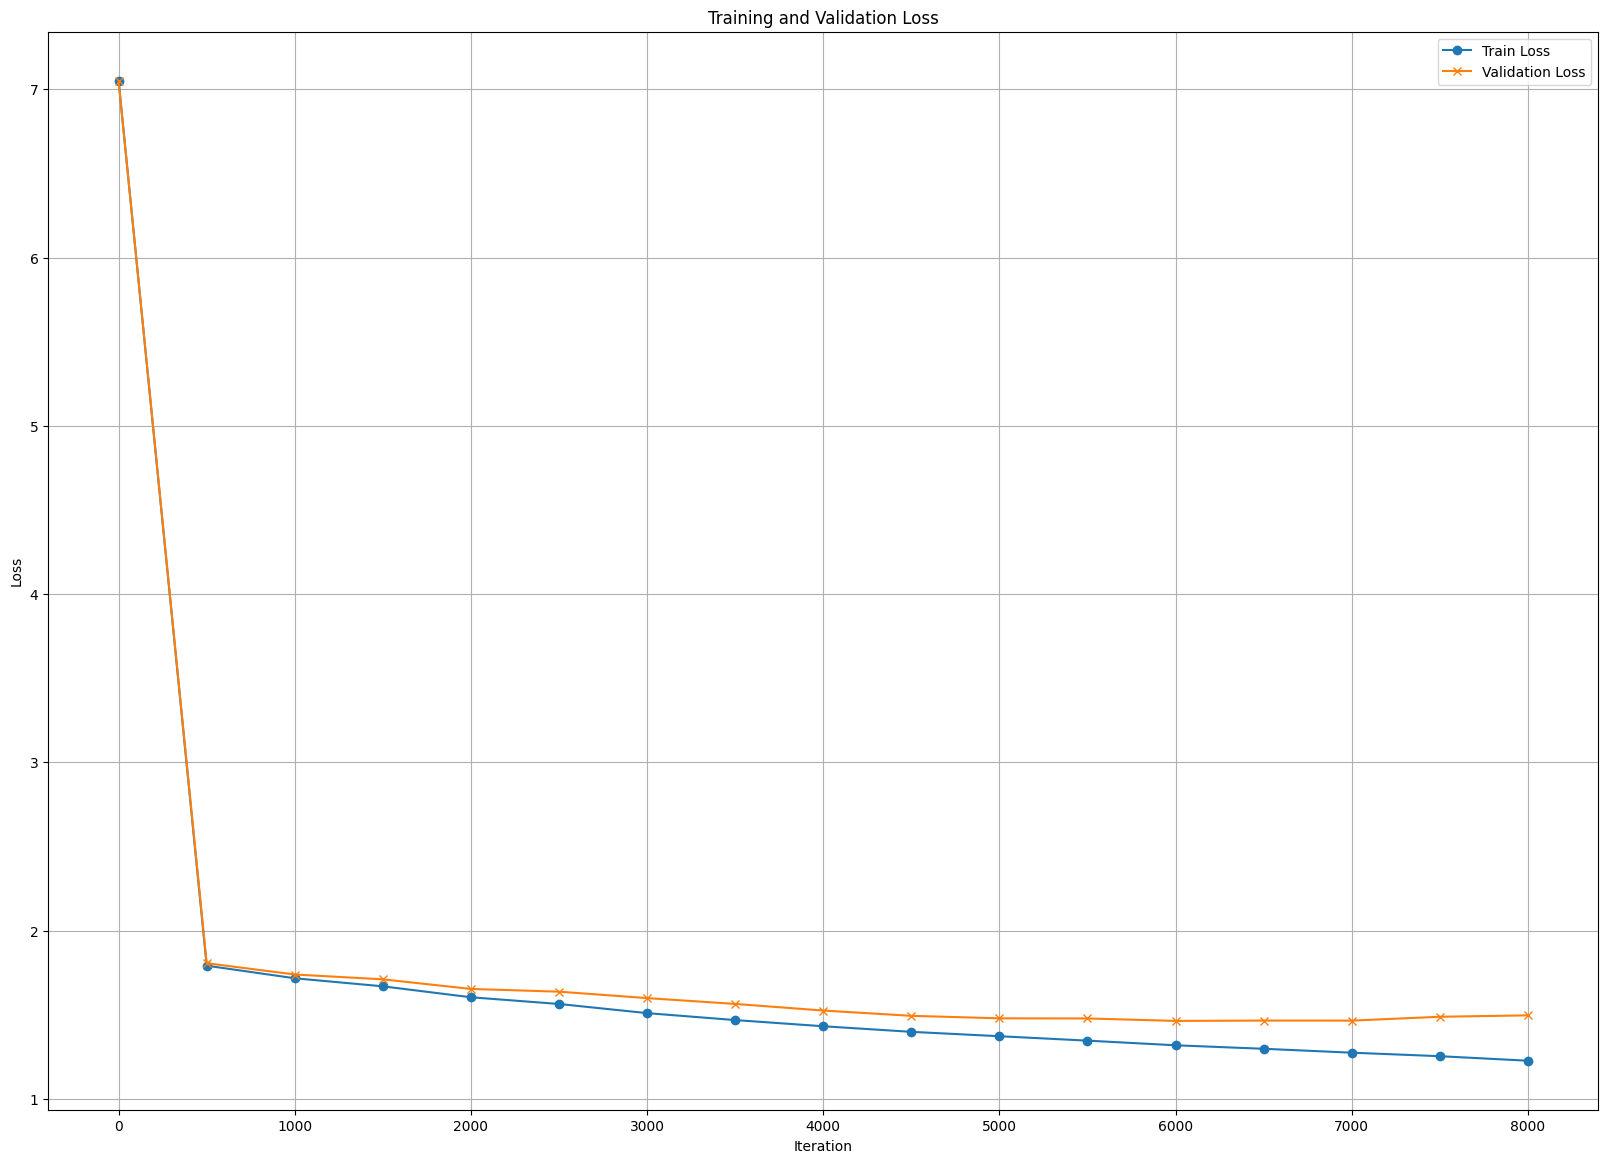

In [13]:
model = GPTLanguageModel()
m = model.to(device)

print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

train_losses = []
val_losses = []
steps = []

best_val_loss = float('inf')
save_path = "model_weights_part1.pth"  #torch.save(model1.state_dict(), "model_weights_part1.pth")

optimizer = torch.optim.AdamW(m.parameters(), lr=learning_rate)

for iter in range(max_iters):

    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        train_loss = losses['train']
        val_loss = losses['val']


        steps.append(iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"step {iter}: train loss {train_loss:.4f}, val loss {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(m.state_dict(), "model_weights_part1.pth")
            print(f"Best model (val loss = {val_loss:.4f})")

    xb, yb = get_batch('train')
    logits, loss = m(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

plt.figure(figsize=(20,14))
plt.plot(steps, train_losses, label="Train Loss", marker='o')
plt.plot(steps, val_losses, label="Validation Loss", marker='x')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## LOAD MODEL

In [14]:
model = GPTLanguageModel()   
m = model.to(device)

In [15]:
m.load_state_dict(torch.load("model_weights_part1.pth"))

<All keys matched successfully>

## Testing on sample equations

In [16]:
m.eval()
prompt = "(5*1)*1="

context = torch.tensor(
    encode(prompt),
    dtype=torch.long,
    device=device
).unsqueeze(0) 


out = m.generate(context, max_new_tokens=2)
print(decode(out[0].tolist()))

(5*1)*1=5



In [23]:
m.eval()
prompt = "(6*5)/7="

context = torch.tensor(
    encode(prompt),
    dtype=torch.long,
    device=device
).unsqueeze(0) 


out = m.generate(context, max_new_tokens=2)
print(decode(out[0].tolist()))

(6*5)/7=4



In [17]:
m.eval()
prompt = "(8*6)+8="

context = torch.tensor(
    encode(prompt),
    dtype=torch.long,
    device=device
).unsqueeze(0) 


out = m.generate(context, max_new_tokens=2)
print(decode(out[0].tolist()))

(8*6)+8=44



In [18]:
m.eval()
prompt = "(2+8)*4="

context = torch.tensor(
    encode(prompt),
    dtype=torch.long,
    device=device
).unsqueeze(0) 


out = m.generate(context, max_new_tokens=2)
print(decode(out[0].tolist()))

(2+8)*4=28



In [19]:
m.eval()
prompt = "(9*6)+8="

context = torch.tensor(
    encode(prompt),
    dtype=torch.long,
    device=device
).unsqueeze(0) 


out = m.generate(context, max_new_tokens=2)
print(decode(out[0].tolist()))

(9*6)+8=44



In [32]:
m.eval()
prompt = "(6*6)+8="

context = torch.tensor(
    encode(prompt),
    dtype=torch.long,
    device=device
).unsqueeze(0) 


out = m.generate(context, max_new_tokens=2)
print(decode(out[0].tolist()))

(6*6)+8=18



## Operations of type  "a op b = c"  op -> '+' or '-' or '*' or '/'

In [18]:
m.eval()
prompt = "22*39="

context = torch.tensor(encode(prompt),dtype=torch.long, device=device).unsqueeze(0) 

out = m.generate(context, max_new_tokens=2)
print(decode(out[0].tolist()))

22*39=858


In [24]:
m.eval()
prompt = "95+50="

context = torch.tensor(encode(prompt),dtype=torch.long, device=device).unsqueeze(0) 

out = m.generate(context, max_new_tokens=2)
print(decode(out[0].tolist()))

95+50=144


In [25]:
m.eval()
prompt = "26-68="

context = torch.tensor(encode(prompt),dtype=torch.long, device=device).unsqueeze(0) 

out = m.generate(context, max_new_tokens=2)
print(decode(out[0].tolist()))

26-68=-42


In [26]:
m.eval()
prompt = "18/92="

context = torch.tensor(encode(prompt),dtype=torch.long, device=device).unsqueeze(0) 

out = m.generate(context, max_new_tokens=2)
print(decode(out[0].tolist()))

18/92=0



In [88]:
m.eval()
prompt = "4+8="

context = torch.tensor(encode(prompt),dtype=torch.long, device=device).unsqueeze(0) 

out = m.generate(context, max_new_tokens=2)
print(decode(out[0].tolist()))

4+8=12



In [89]:
m.eval()
prompt = "9*2="

context = torch.tensor(encode(prompt),dtype=torch.long, device=device).unsqueeze(0) 

out = m.generate(context, max_new_tokens=2)
print(decode(out[0].tolist()))

9*2=18



In [90]:
m.eval()
prompt = "0-8="

context = torch.tensor(encode(prompt),dtype=torch.long, device=device).unsqueeze(0) 

out = m.generate(context, max_new_tokens=2)
print(decode(out[0].tolist()))

0-8=-8


In [91]:
m.eval()
prompt = "8-6="

context = torch.tensor(encode(prompt),dtype=torch.long, device=device).unsqueeze(0) 

out = m.generate(context, max_new_tokens=2)
print(decode(out[0].tolist()))

8-6=2



In [92]:
m.eval()
prompt = "8/4="

context = torch.tensor(encode(prompt),dtype=torch.long, device=device).unsqueeze(0) 

out = m.generate(context, max_new_tokens=2)
print(decode(out[0].tolist()))

8/4=2



# EVALUATION

In [27]:
def extract_operator(expr):
    expr = expr.replace(" ", "")
    for op in ["+", "-", "*", "/"]:
        if op in expr:
            return op
    return None

def normalize(s):
    return s.replace(" ", "").replace("\n", "").strip()

samples = []
with open(r"/kaggle/input/final-maths-dataset/dataset.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        inp = normalize(row["input"])
        out = normalize(row["output"])
        if "(" in inp or ")" in inp:
            continue
        samples.append((inp, out))

print(f"Evaluating {len(samples)} basic maths expressions")

# stats now also stores wrong examples
stats = defaultdict(lambda: {
    "correct": 0,
    "total": 0,
    "wrong": []
})

with torch.no_grad():
    for inp, target in tqdm(samples, desc="Evaluating"):
        op = extract_operator(inp)

        context = torch.tensor(
            encode(inp),
            dtype=torch.long,
            device=device
        ).unsqueeze(0)

        out = model.generate(context, max_new_tokens=2)
        pred = decode(out[0].tolist())
        generated = normalize(pred[len(inp):])

        stats[op]["total"] += 1

        if generated == target:
            stats[op]["correct"] += 1


print("\nBasic maths evaluation (a op b = c)\n")

overall_correct = 0
overall_total = 0

for op in sorted(stats.keys()):
    c = stats[op]["correct"]
    t = stats[op]["total"]
    acc = c / t if t > 0 else 0

    overall_correct += c
    overall_total += t

    print(f"Operator {op} : {c}/{t} → Accuracy = {acc:.3f}")


print("---------------------------")
print(
    f"Overall Accuracy : "
    f"{overall_correct}/{overall_total} → "
    f"{overall_correct / overall_total:.3f}")


Evaluating 2225 basic maths expressions


Evaluating: 100%|██████████| 2225/2225 [00:52<00:00, 42.58it/s]


Basic maths evaluation (a op b = c)

Operator * : 582/612 → Accuracy = 0.951
Operator + : 580/617 → Accuracy = 0.940
Operator - : 510/550 → Accuracy = 0.927
Operator / : 418/446 → Accuracy = 0.937
---------------------------
Overall Accuracy : 2090/2225 → 0.939


## Evaluating basic maths with max_new_tokens = 3

In [28]:
def extract_operator(expr):
    expr = expr.replace(" ", "")
    for op in ["+", "-", "*", "/"]:
        if op in expr:
            return op
    return None

def normalize(s):
    return s.replace(" ", "").replace("\n", "").strip()

samples = []
with open(r"/kaggle/input/final-maths-dataset/dataset.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        inp = normalize(row["input"])
        out = normalize(row["output"])
        if "(" in inp or ")" in inp:
            continue
        samples.append((inp, out))

print(f"Evaluating {len(samples)} basic maths expressions")

# stats now also stores wrong examples
stats = defaultdict(lambda: {
    "correct": 0,
    "total": 0,
    "wrong": []
})

with torch.no_grad():
    for inp, target in tqdm(samples, desc="Evaluating"):
        op = extract_operator(inp)

        context = torch.tensor(
            encode(inp),
            dtype=torch.long,
            device=device
        ).unsqueeze(0)

        out = model.generate(context, max_new_tokens=3)
        pred = decode(out[0].tolist())
        generated = normalize(pred[len(inp):])

        stats[op]["total"] += 1

        if generated == target:
            stats[op]["correct"] += 1
        else:
            stats[op]["wrong"].append({
                "input": inp,
                "expected": target,
                "predicted": generated
            })

print("\nBasic maths evaluation (a op b = c)\n")

overall_correct = 0
overall_total = 0

for op in sorted(stats.keys()):
    c = stats[op]["correct"]
    t = stats[op]["total"]
    acc = c / t if t > 0 else 0

    overall_correct += c
    overall_total += t

    print(f"Operator {op} : {c}/{t} → Accuracy = {acc:.3f}")

print("---------------------------")
print(
    f"Overall Accuracy : "
    f"{overall_correct}/{overall_total} → "
    f"{overall_correct / overall_total:.3f}")

Evaluating 2225 basic maths expressions


Evaluating: 100%|██████████| 2225/2225 [01:18<00:00, 28.46it/s]


Basic maths evaluation (a op b = c)

Operator * : 67/612 → Accuracy = 0.109
Operator + : 46/617 → Accuracy = 0.075
Operator - : 266/550 → Accuracy = 0.484
Operator / : 0/446 → Accuracy = 0.000
---------------------------
Overall Accuracy : 379/2225 → 0.170


## Evaluating for Compound Expressions

In [29]:
samples = []
with open("/kaggle/input/final-maths-dataset/dataset.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        inp = normalize(row["input"])
        out = normalize(row["output"])

        if "(" in inp and ")" in inp:
            samples.append((inp, out))

print(f"Evaluating {len(samples)} compound maths expressions")

total = 0
correct = 0

with torch.no_grad():
    for inp, target in tqdm(samples, desc="Evaluating compound statements"):
        context = torch.tensor(
            encode(inp),
            dtype=torch.long,
            device=device
        ).unsqueeze(0)

        out = model.generate(context, max_new_tokens=2)
        pred = decode(out[0].tolist())

        generated = normalize(pred[len(inp):])

        total += 1
        if generated == target:
            correct += 1

accuracy = correct / total if total > 0 else 0
print(f"\nCOMPOUND STATEMENTS EVALUATION")
print(f"Correct : {correct}/{total} → Accuracy = {accuracy:.3f}")


Evaluating 801 compound maths expressions


Evaluating compound statements: 100%|██████████| 801/801 [00:18<00:00, 42.79it/s]


COMPOUND STATEMENTS EVALUATION
Correct : 464/801 → Accuracy = 0.579


# BOOLEAN GPT

In [12]:
with open("/kaggle/input/boolean-dataset-2/boolean_dataset.txt", "r") as f:
    lines = f.read().splitlines()
text = "\n".join(lines)

In [13]:
print(text)

False OR False = False
False OR True = True
True OR False = True
True OR True = True
False AND False = False
False AND True = False
True AND False = False
True AND True = True
NOT False = True
NOT True = False
False XOR False = False
False XOR True = True
True XOR False = True
True XOR True = False
(False OR False) AND True = False
(False OR False) AND False = False
(False OR True) AND True = True
(False OR True) AND False = False
(True OR False) AND True = True
(True OR False) AND False = False
(True OR True) AND True = True
(True OR True) AND False = False
(False AND False) OR True = True
(False AND False) OR False = False
(False AND True) OR True = True
(False AND True) OR False = False
(True AND False) OR True = True
(True AND False) OR False = False
(True AND True) OR True = True
(True AND True) OR False = True 
(False AND False) XOR True = True
(False AND False) XOR False = False
(False AND True) XOR True = True
(False AND True) XOR False = False
(True AND False) XOR True = True


In [14]:
import re
def tokenize(text):
    """
    Tokenizes logical expressions into words and symbols.
    Treats (, ) as separate tokens.
    """
    pattern = r'\(|\)|\w+|='
    tokens = re.findall(pattern, text)
    return tokens

tokens = list(set(tokenize(text)))
tokens.append(" ") 
tokens.append('\n')
print(tokens)

['=', 'XOR', 'False', 'OR', 'AND', 'True', ')', 'NOT', '(', ' ', '\n']


In [15]:
stoi = {tok: i for i, tok in enumerate(tokens)}
itos = {i: tok for tok, i in stoi.items()}

In [16]:
print(stoi)
print(itos)

{'=': 0, 'XOR': 1, 'False': 2, 'OR': 3, 'AND': 4, 'True': 5, ')': 6, 'NOT': 7, '(': 8, ' ': 9, '\n': 10}
{0: '=', 1: 'XOR', 2: 'False', 3: 'OR', 4: 'AND', 5: 'True', 6: ')', 7: 'NOT', 8: '(', 9: ' ', 10: '\n'}


In [17]:
def tokenize_text(s, vocab):
    tokens = []
    i = 0
    vocab_sorted = sorted(vocab, key=len, reverse=True)
    while i < len(s):
        for tok in vocab_sorted:
            if s.startswith(tok, i):
                tokens.append(tok)
                i += len(tok)
                break
        else:
            raise ValueError(f"Unknown token at position {i}: '{s[i]}'")
    return tokens

In [18]:
encode = lambda s: [stoi[tok] for tok in tokenize_text(s,tokens)]
decode = lambda l: ' '.join([itos[i] for i in l])

In [19]:
encode("True XOR False = True")

[5, 9, 1, 9, 2, 9, 0, 9, 5]

In [20]:
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) 
train_data = data[:n]
val_data = data[n:]

In [39]:
batch_size = 60 #80 
block_size = 12 
max_iters = 5000
eval_interval = 500
learning_rate = 3e-4 #1e-4
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 128 
n_head = 4
n_layer = 4
dropout = 0.2
print(device)

cuda


In [40]:
vocab_size = len(tokens)

# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss():
    out = {}
    m.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = m(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    m.train()
    return out

class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # input of size (batch, time-step, channels)
        # output of size (batch, time-step, head size)
        B,T,C = x.shape
        k = self.key(x)   # (B,T,hs)
        q = self.query(x) # (B,T,hs)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * k.shape[-1]**-0.5 # (B, T, hs) @ (B, hs, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,hs)
        out = wei @ v # (B, T, T) @ (B, T, hs) -> (B, T, hs)
        return out

class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(head_size * num_heads, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class GPTLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

        # better init, not covered in the original GPT video, but important, will cover in followup video
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.argmax(logits, dim=-1, keepdim=True) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

0.796171 M parameters
step 0: train loss 2.3665, val loss 2.3839
step 500: train loss 0.4652, val loss 0.4832
step 1000: train loss 0.4399, val loss 0.5245
step 1500: train loss 0.4147, val loss 0.5977
step 2000: train loss 0.3988, val loss 0.6631
step 2500: train loss 0.3919, val loss 0.6955
step 3000: train loss 0.3852, val loss 0.7083
step 3500: train loss 0.3815, val loss 0.7415
step 4000: train loss 0.3807, val loss 0.8027
step 4500: train loss 0.3818, val loss 0.8024
step 4999: train loss 0.3804, val loss 0.8456
Final model saved.


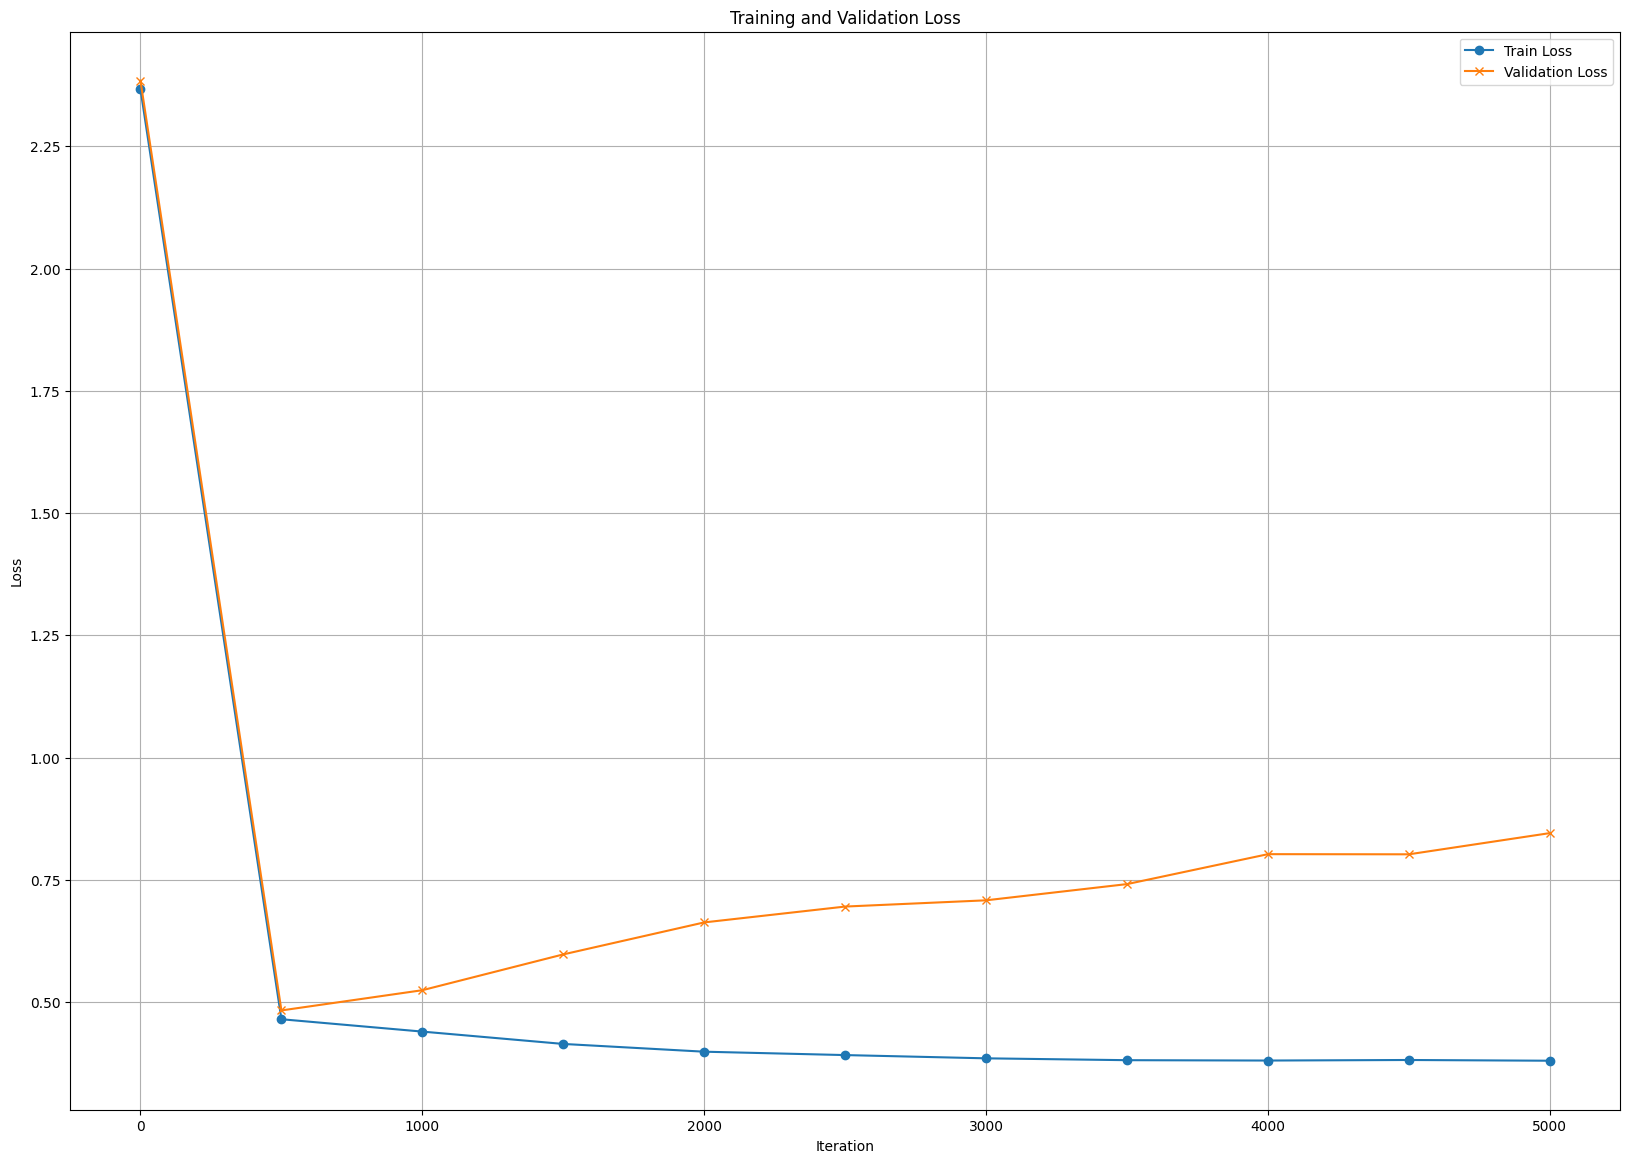

In [41]:
model = GPTLanguageModel()
m = model.to(device)
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')
train_losses = []
val_losses = []
steps = []
optimizer = torch.optim.AdamW(m.parameters(), lr=learning_rate)
for iter in range(max_iters):

    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        train_loss = losses['train']
        val_loss = losses['val']

        steps.append(iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"step {iter}: train loss {train_loss:.4f}, val loss {val_loss:.4f}")

    xb, yb = get_batch('train')
    logits, loss = m(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

torch.save(m.state_dict(), "model_weights_part2.pth")
print("Final model saved.")

plt.figure(figsize=(20,14))
plt.plot(steps, train_losses, label="Train Loss", marker='o')
plt.plot(steps, val_losses, label="Validation Loss", marker='x')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig("training_validation_loss_bool.png", dpi=300, bbox_inches='tight')
plt.show()


## Load Model

In [42]:
model = GPTLanguageModel()   # must match training architecture
m = model.to(device)

In [43]:
m.load_state_dict(torch.load("model_weights_part2.pth"))

<All keys matched successfully>

In [36]:
m.eval()
prompt = "(True XOR False) AND True ="
context = torch.tensor(encode(prompt),dtype=torch.long,device=device).unsqueeze(0) 
out = m.generate(context, max_new_tokens=2)
print(decode(out[0].tolist()))

( True   XOR   False )   AND   True   =   False


In [27]:
m.eval()
prompt = "NOT True ="
context = torch.tensor(encode(prompt),dtype=torch.long,device=device).unsqueeze(0)         
out = m.generate(context, max_new_tokens=2)
print(decode(out[0].tolist()))

NOT   True   =   False


In [28]:
m.eval()
prompt = "(True AND True) OR False ="
context = torch.tensor(encode(prompt),dtype=torch.long,device=device).unsqueeze(0)        
out = m.generate(context, max_new_tokens=2)
print(decode(out[0].tolist()))

( True   AND   True )   OR   False   =   False


## Evaluating Model

In [37]:
def evaluate_boolean_dataset(model, dataset_lines, max_new_tokens=2):
    model.eval()
    correct = 0
    total = 0
    wrong = []
    for line in lines:
        try:
            inp, target = line.split("=")
        except:
            continue
        inp = inp.strip() + " = "
        target = target.strip()
        expected_full = inp + target
        context = torch.tensor(
            encode(inp),
            dtype=torch.long,
            device=device
        ).unsqueeze(0)
        out = model.generate(context, max_new_tokens=max_new_tokens)
        decoded = decode(out[0].tolist()).strip()
        total += 1
        if decoded.replace(" ", "") == expected_full.replace(" ", ""):
            correct += 1
        else:
            wrong.append({
                "expected": expected_full,
                "predicted": decoded
            })

    accuracy = correct / total if total > 0 else 0.0
    return accuracy, wrong

In [38]:
accuracy, errors = evaluate_boolean_dataset(m, text)
print(f"\nFinal Accuracy: {accuracy*100:.2f}%")
print(f"Correct: {len(lines) - len(errors)} / {len(lines)}")
if errors:
    print("\nSample mistakes:")
    for e in errors[:5]:
        print(e)


Final Accuracy: 83.87%
Correct: 54 / 64

Sample mistakes:
{'expected': '(True OR False) AND True = True', 'predicted': '( True   OR   False )   AND   True   =   False'}
{'expected': '(True AND True) OR False = True', 'predicted': '( True   AND   True )   OR   False   =   False'}
{'expected': '(True AND True) XOR True = False', 'predicted': '( True   AND   True )   XOR   True   =   True'}
{'expected': '(True AND True) XOR False = True', 'predicted': '( True   AND   True )   XOR   False   =   False'}
{'expected': '(False XOR True) AND True = True', 'predicted': '( False   XOR   True )   AND   True   =   False'}
